In [1]:
import pandas as pd
import sys
import numpy as np

In [2]:
sys.path.append("..")

In [3]:
from src.data_loader import load_data, save_data_to_csv

In [4]:
data = load_data("QQQ", "2010-01-01", "2026-06-23")

[*********************100%***********************]  1 of 1 completed


In [6]:
start = data.index[0].year
end = data.index[-1].year

end- start

16

In [7]:
start_year = data.index[0].year

train_window = 5
forecast_window = 1

for i in range((data.index[-1].year-data.index[0].year)-train_window + 1):

    train_start = start_year
    train_end = start_year + train_window

    forecast_start = train_end
    forecast_end = forecast_start + forecast_window

    train_data = data[
        (data.index.year >= train_start) &
        (data.index.year < train_end)
    ]

    forecast_data = data[
        (data.index.year >= forecast_start) &
        (data.index.year < forecast_end)
    ]

    print(
        f"Train: {train_start}-{train_end-1}"
    )

    print(
        f"Forecast: {forecast_start}"
    )

    start_year += 1

Train: 2010-2014
Forecast: 2015
Train: 2011-2015
Forecast: 2016
Train: 2012-2016
Forecast: 2017
Train: 2013-2017
Forecast: 2018
Train: 2014-2018
Forecast: 2019
Train: 2015-2019
Forecast: 2020
Train: 2016-2020
Forecast: 2021
Train: 2017-2021
Forecast: 2022
Train: 2018-2022
Forecast: 2023
Train: 2019-2023
Forecast: 2024
Train: 2020-2024
Forecast: 2025
Train: 2021-2025
Forecast: 2026


In [8]:
save_data_to_csv(data, "../data/QQQ_data.csv")

In [6]:
data = pd.read_csv("../data/QQQ_data.csv")

In [7]:
data = data[["Close"]]
data["log_returns"] = np.log(data).diff()

In [8]:
from models.garch import fit_garch_1_1, forecast_garch_1_1_volatility
from models.har import fit_har_rv, forecast_har_rv_volatility 

In [9]:
a = fit_garch_1_1(data[["log_returns"]])

mu          0.104196
omega       0.047105
alpha[1]    0.127277
beta[1]     0.845479
Name: params, dtype: float64

In [13]:
result = forecast_garch_1_1_volatility(a)

In [14]:
result

np.float64(0.01840306436530191)

In [15]:
b = fit_har_rv(data[["log_returns"]])

In [16]:
har_result = forecast_har_rv_volatility(b)

In [17]:
har_result

0.016414464657420188

In [18]:
from models.lstm import create_sequences, fit_lstm, forecast_lstm_volatility

In [19]:
data_train = data[data.index < "2020-01-01"]["log_returns"]

In [20]:
model = fit_lstm(data_train)

In [21]:
model

LSTMVolatilityModel(
  (lstm): LSTM(1, 10, batch_first=True)
  (fc): Linear(in_features=10, out_features=1, bias=True)
)

In [22]:
test_window = data["log_returns"].dropna().iloc[-30:]

forecast = forecast_lstm_volatility(
    model,
    test_window
)

print(forecast)

0.0040331005428014335


In [23]:
from models import egarch, garch, gjr_garch, gru, har, lstm

In [24]:
models_df = pd.DataFrame({
    "model": [
        "GARCH",
        "EGARCH",
        "GJR-GARCH",
        "HAR",
        "LSTM",
        "GRU"
    ],
    "fit_function": [
        garch.fit_garch_1_1,
        egarch.fit_egarch_1_1,
        gjr_garch.fit_gjrgarch_1_1,
        har.fit_har_rv,
        lstm.fit_lstm,
        gru.fit_gru
    ],
    "forecast_function": [
        garch.forecast_garch_1_1_volatility,
        egarch.forecast_egarch_1_1_volatility,
        gjr_garch.forecast_gjrgarch_1_1_volatility,
        har.forecast_har_rv_volatility,
        lstm.forecast_lstm_volatility,
        gru.forecast_gru_volatility
    ]
})

In [25]:
models_df

,model,fit_function,forecast_function
0,GARCH,<function fit_garch_1_1 at 0x0000023837CE3420>,<function forecast_garch_1_1_volatility at 0x0...
1,EGARCH,<function fit_egarch_1_1 at 0x000002385B85E520>,<function forecast_egarch_1_1_volatility at 0x...
2,GJR-GARCH,<function fit_gjrgarch_1_1 at 0x000002385B85EAC0>,<function forecast_gjrgarch_1_1_volatility at ...
3,HAR,<function fit_har_rv at 0x000002384A36FCE0>,<function forecast_har_rv_volatility at 0x0000...
4,LSTM,<function fit_lstm at 0x000002385714D9E0>,<function forecast_lstm_volatility at 0x000002...
5,GRU,<function fit_gru at 0x000002385B83B600>,<function forecast_gru_volatility at 0x0000023...


In [5]:
import sys
sys.path.append("../src")

In [6]:
from training import train_models

In [7]:
result, loss_df = train_models(data)

Train: 2010-2014
Forecast: 2015
Train: 2011-2015
Forecast: 2016
Train: 2012-2016
Forecast: 2017
Train: 2013-2017
Forecast: 2018
Train: 2014-2018
Forecast: 2019
Train: 2015-2019
Forecast: 2020
Train: 2016-2020
Forecast: 2021
Train: 2017-2021
Forecast: 2022
Train: 2018-2022
Forecast: 2023
Train: 2019-2023
Forecast: 2024
Train: 2020-2024
Forecast: 2025
Train: 2021-2025
Forecast: 2026


In [9]:
pivoted = loss_df.pivot(index="epoch", columns=["train_start", "model"], values=["train_loss", "validation_loss"])

In [10]:
pivoted

train_loss                                                    \
train_start       2010                2011                2012             
model             LSTM       GRU      LSTM       GRU      LSTM       GRU   
epoch                                                                      
1             0.965350  0.474435  0.934784  0.739923  0.991337  0.750802   
2             0.914521  0.174152  0.894250  0.379519  0.932725  0.226267   
3             0.892273  0.105899  0.881311  0.165473  0.911438  0.118318   
4             0.875610  0.087560  0.875912  0.101996  0.897123  0.108100   
5             0.864482  0.072223  0.862484  0.083661  0.892292  0.094788   
...                ...       ...       ...       ...       ...       ...   
93                 NaN       NaN       NaN       NaN       NaN       NaN   
94                 NaN       NaN       NaN       NaN       NaN       NaN   
95                 NaN       NaN       NaN       NaN       NaN       NaN   
96                 NaN       NaN       NaN       NaN       NaN       NaN   
97                 NaN       NaN       NaN       NaN       NaN       NaN   

                                                     ... validation_loss  \
train_start      2013                2014            ...            2017   
model            LSTM       GRU      LSTM       GRU  ...            LSTM   
epoch                                                ...                   
1            0.973195  0.624466  1.021576  0.758778  ...        0.789487   
2            0.933650  0.190913  0.973601  0.368920  ...        0.759871   
3            0.929470  0.096390  0.965729  0.179021  ...        0.750320   
4            0.912126  0.078943  0.953361  0.128718  ...        0.746200   
5            0.907461  0.069521  0.941455  0.101542  ...        0.742372   
...               ...       ...       ...       ...  ...             ...   
93                NaN       NaN       NaN       NaN  ...             NaN   
94                NaN       NaN       NaN       NaN  ...             NaN   
95                NaN       NaN       NaN       NaN  ...             NaN   
96                NaN       NaN       NaN       NaN  ...             NaN   
97                NaN       NaN       NaN       NaN  ...             NaN   

                                                                         \
train_start                2018                2019                2020   
model             GRU      LSTM       GRU      LSTM       GRU      LSTM   
epoch                                                                     
1            0.181036  0.928885  1.001846  0.894445  0.266877  0.986408   
2            0.055751  0.928190  0.414423  0.898210  0.090292  0.969823   
3            0.046649  0.925857  0.050998  0.897304  0.061981  0.959231   
4            0.040014  0.928679  0.045948  0.903093  0.059471  0.957449   
5            0.035405  0.931776  0.039157  0.905310  0.050129  0.952475   
...               ...       ...       ...       ...       ...       ...   
93           0.008898       NaN       NaN       NaN       NaN       NaN   
94           0.009002       NaN       NaN       NaN       NaN       NaN   
95           0.008892       NaN       NaN       NaN       NaN       NaN   
96                NaN       NaN       NaN       NaN       NaN       NaN   
97                NaN       NaN       NaN       NaN       NaN       NaN   

                                           
train_start                2021            
model             GRU      LSTM       GRU  
epoch                                      
1            0.435816  0.990990  0.785333  
2            0.096589  1.007076  0.451873  
3            0.074223  0.987440  0.414966  
4            0.058381  0.990535  0.365703  
5            0.049915  0.980319  0.329024  
...               ...       ...       ...  
93                NaN       NaN  0.061363  
94                NaN       NaN  0.061582  
95                NaN       NaN  0.061714  
96                NaN       NaN 

<Axes: xlabel='epoch'>

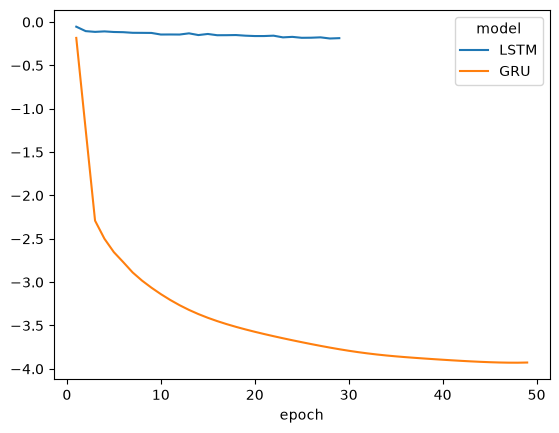

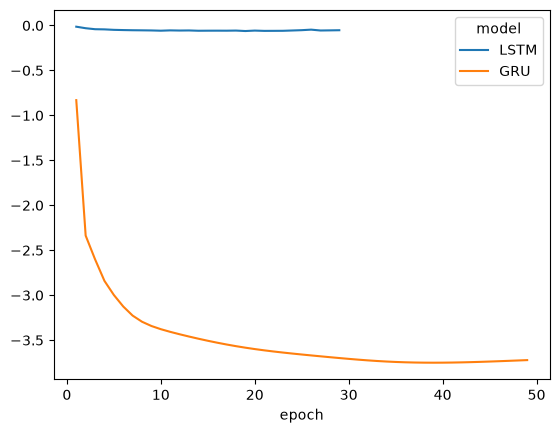

In [11]:
np.log(pivoted["train_loss"][2020]).plot()
np.log(pivoted["validation_loss"][2020]).plot()

<Axes: xlabel='date'>

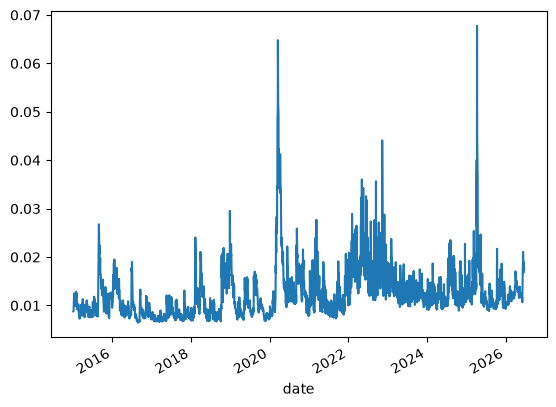

In [16]:
result["HAR"].plot()

In [17]:
data_zaro = data[["Close"]]
data_zaro

Price,Close
Date,
2010-01-04,40.246555
2010-01-05,40.246555
2010-01-06,40.003796
2010-01-07,40.029789
2010-01-08,40.359272
...,...
2026-06-15,743.183289
2026-06-16,729.058777
2026-06-17,721.716858


In [18]:
data["realized_vol"] = (np.log(data["Close"]).diff()**2)**0.5

np.float64(0.09699344991289356)

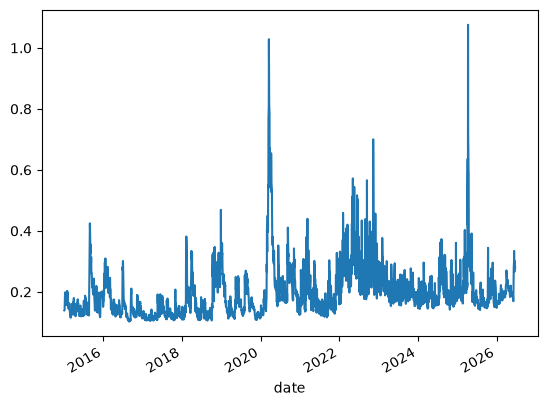

In [30]:

#(data.realized_vol * np.sqrt(252)).plot()
(result["HAR"] * np.sqrt(252)).plot()
np.min((result["GARCH"] * np.sqrt(252)))

In [11]:
from utils import calculate_log_returns

In [12]:
log_returns = calculate_log_returns(data)

log_returns["log_returns"].abs().describe()

count    4140.000000
mean        0.009037
std         0.009399
min         0.000000
25%         0.002708
50%         0.006389
75%         0.012343
max         0.127592
Name: log_returns, dtype: float64